# Causomic User Manual (MS proteomics example)

This notebook reviews the main functions and workflow in Causomic.

Causomic is designed to perform causal inference on different types of omics 
experiments. The goal is to predict the effect of interventions 
(e.g., inhibition) on the biological system.

## General imports

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
%matplotlib inline

/tmp/ipykernel_9329/2462056428.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax.boxplot(recall_data, positions=[1, 4, 7], widths=0.6,
/tmp/ipykernel_9329/2462056428.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(precision_data, positions=[2, 5, 8], widths=0.6,


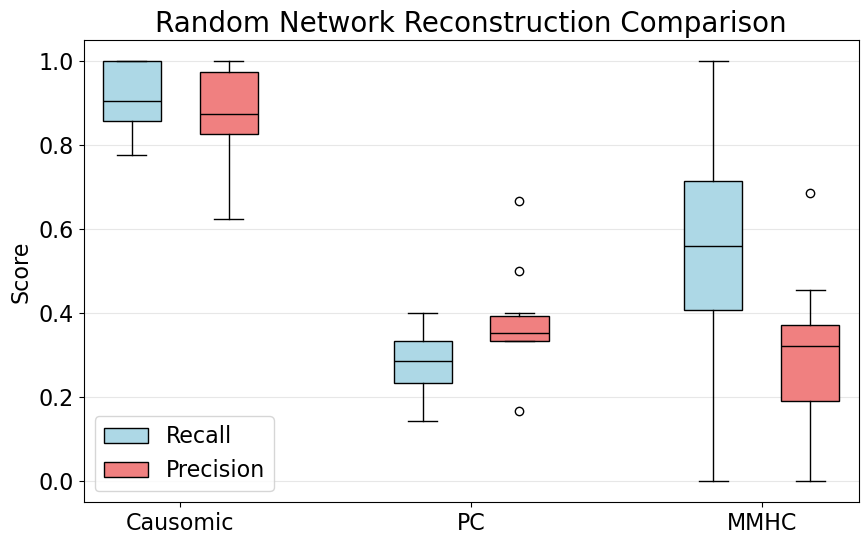

In [16]:
data = pd.read_csv('../run_graph_sim_results.csv')

fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for boxplot
recall_data = [data['causomic_recall'], data['pc_recall'], data['mmhc_recall']]
precision_data = [data['causomic_precision'], data['pc_precision'], data['mmhc_precision']]

positions_recall = [1, 2, 4, 5, 7, 8]
positions_precision = [1.5, 2.5, 4.5, 5.5, 7.5, 8.5]

# Create boxplots
bp1 = ax.boxplot(recall_data, positions=[1, 4, 7], widths=0.6, 
                 patch_artist=True, labels=['Causomic', 'PC', 'MMHC'],
                 boxprops=dict(facecolor='lightblue'),
                 medianprops=dict(color='black'))
bp2 = ax.boxplot(precision_data, positions=[2, 5, 8], widths=0.6,
                 patch_artist=True, labels=['Causomic', 'PC', 'MMHC'],
                 boxprops=dict(facecolor='lightcoral'),
                 medianprops=dict(color='black'))

ax.set_ylabel('Score', fontsize=16)
ax.tick_params(axis='both', labelsize=16)
ax.set_title('Random Network Reconstruction Comparison', fontsize=20)
ax.set_xticks([1.5, 4.5, 7.5])
ax.set_xticklabels(['Causomic', 'PC', 'MMHC'])
ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ['Recall', 'Precision'], fontsize=16 )
ax.grid(axis='y', alpha=0.3)

## Input data

`causomic` takes as input the output of the `MSstats` `dataProcess` function.
The `dataProcess` function outputs a list of mutitple `data.frame`. 
Specifically, causomic takes as input the `ProteinLevelData` `data.frame` 
output of `dataProcess`. The `ProteinLevelData` is the summarized protein-level 
data, which includes one value per protein per MS run. This is contrast to 
the actual output of MS-based experiments (generally either the precursor or 
fragment, depending on the acquisition method / MS1 vs MS2 quantification).

`MSstats` is an R package which can be used to process identified and 
quantified MS-based proteomics data. Eventually the goal would be to call this 
function directly from `causomic`. For now, you can find R code to run this 
function in the notes of the `causomic.data_analysis.dataProcess` function.

In this example we will use the small molecule inhibition dataset from Talus 
Bio.

In [2]:
input_data = pd.read_csv("../data/Talus/ProteinLevelData.csv")
input_data.head()

,RUN,Protein,LogIntensities,originalRUN,GROUP,SUBJECT,TotalGroupMeasurements,NumMeasuredFeature,MissingPercentage,more50missing,NumImputedFeature
0,1,1433B_HUMAN,12.873423,230719_THP-1_Chrom_end2end_Plate1_DMSO_A02_DIA,DMSO,2,1210,10,0.0,False,0
1,2,1433B_HUMAN,12.866217,230719_THP-1_Chrom_end2end_Plate1_DMSO_A05_DIA,DMSO,5,1210,10,0.0,False,0
2,3,1433B_HUMAN,12.686827,230719_THP-1_Chrom_end2end_Plate1_DMSO_A10_DIA,DMSO,10,1210,10,0.0,False,0
3,4,1433B_HUMAN,12.625462,230719_THP-1_Chrom_end2end_Plate1_DMSO_A12_DIA,DMSO,12,1210,10,0.0,False,0
4,5,1433B_HUMAN,12.538365,230719_THP-1_Chrom_end2end_Plate1_DMSO_B01_DIA,DMSO,13,1210,10,0.0,False,0


## Data pre-processing

In this notebook we will build a model around the dBET6 inhibitor. We will hold 
out the actualy dBET6 data for validation and split the remaining data for 
network construction and causal model training.

The first step is to convert the UNIPROT IDs to gene names.

In [3]:
from indra.databases import uniprot_client, hgnc_client

def uniprot_to_hgnc_name(uniprot_mnemonic):
    """Get an HGNC ID from a UniProt mnemonic."""
    uniprot_id = uniprot_client.get_id_from_mnemonic(uniprot_mnemonic)
    if uniprot_id:
        return uniprot_client.get_gene_name(uniprot_id)
    else:
        return None
    
input_data.loc[:, "Protein"] = input_data["Protein"].apply(uniprot_to_hgnc_name)
input_data.head()

,RUN,Protein,LogIntensities,originalRUN,GROUP,SUBJECT,TotalGroupMeasurements,NumMeasuredFeature,MissingPercentage,more50missing,NumImputedFeature
0,1,YWHAB,12.873423,230719_THP-1_Chrom_end2end_Plate1_DMSO_A02_DIA,DMSO,2,1210,10,0.0,False,0
1,2,YWHAB,12.866217,230719_THP-1_Chrom_end2end_Plate1_DMSO_A05_DIA,DMSO,5,1210,10,0.0,False,0
2,3,YWHAB,12.686827,230719_THP-1_Chrom_end2end_Plate1_DMSO_A10_DIA,DMSO,10,1210,10,0.0,False,0
3,4,YWHAB,12.625462,230719_THP-1_Chrom_end2end_Plate1_DMSO_A12_DIA,DMSO,12,1210,10,0.0,False,0
4,5,YWHAB,12.538365,230719_THP-1_Chrom_end2end_Plate1_DMSO_B01_DIA,DMSO,13,1210,10,0.0,False,0


In [4]:
from sklearn.model_selection import train_test_split

input_data = input_data.loc[input_data["GROUP"] != "dBET6"]

input_data_wide = input_data.pivot_table(index="RUN", columns="Protein", values="LogIntensities", aggfunc="mean")

input_data_graph, input_data_scm = train_test_split(
    input_data_wide, test_size=0.5, random_state=42)

In [5]:
input_data_graph.head()

Protein,A1CF,A2M,AAAS,AAGAB,AAK1,AAR2,AASDHPPT,AATF,ABCA3,ABCB10,...,ZRSR2,ZRSR2P1,ZSCAN25,ZSCAN26,ZSWIM3,ZW10,ZXDA,ZYG11B,ZYX,ZZZ3
RUN,,,,,,,,,,,,,,,,,,,,,
42,7.217321,NaN,11.774179,NaN,11.695118,NaN,10.133162,11.934626,13.522731,8.423204,...,9.030490,9.463894,9.215072,10.400758,10.288277,9.998765,10.885349,NaN,8.993248,10.720947
247,8.804482,NaN,11.931839,NaN,11.755837,6.577042,11.109267,11.601988,12.969746,9.392238,...,8.395501,9.579936,9.396897,10.668139,11.028451,9.318077,10.970151,NaN,10.428499,10.824301
177,7.622057,NaN,11.706673,NaN,11.999286,7.484309,10.970427,11.190593,13.181480,8.796233,...,9.763666,NaN,8.730592,10.430159,11.017878,9.553262,10.608868,NaN,10.149459,10.615385
137,7.523807,NaN,11.602732,6.407183,11.743696,8.300333,10.248878,11.411533,13.660185,8.495805,...,9.360220,NaN,8.789850,11.655511,10.630127,9.836357,11.209517,7.941327,10.078853,10.713224
27,NaN,NaN,11.545835,NaN,11.735821,NaN,10.401604,11.395275,13.007195,8.151817,...,9.353156,NaN,9.185766,10.683299,9.803309,9.396024,10.982959,NaN,10.389960,10.509943


## Gene set correlation analysis (optional)

A user may be interested in performing a correlation analysis as part of the 
analysis pipeline. This is particularly helpful when trying to determine 
what gene sets might be of interest to build a network around. `causomic` 
includes a function to determine all pairwise correlations between proteins 
in the dataset.

In [6]:
import causomic.data_analysis.gene_set as gs

corr_data = gs.gen_correlation_matrix(input_data_wide, methods=["pearson"], abs_corr=True)

Computing pearson correlation matrix...


ValueError: cannot insert Protein, already exists

In [ ]:
corr_data["pearson"].head()

,value,index
1,0.566504,"(1433B, 1433E)"
2,0.504387,"(1433B, 1433F)"
3,0.779711,"(1433B, 1433G)"
4,0.557784,"(1433B, 1433S)"
5,0.783680,"(1433B, 1433T)"


## Gene set analysis

`causomic` includes functionality for gene set analysis, in case a user 
wants to analyze specific pathways of interest.

This function takes as input a list of gene sets from MSigDB. It looks at how 
many of the proteins in each gene set are highly correlated.

Additionally, the function can see how many differentially abundant proteins are
in the gene set, if differential analysis results are provided (optional).

In [ ]:
import causomic.data_analysis.gene_set as gs

regulatory_paths = gs.test_gene_sets(corr_data, # Correlation data
                                     input_data.columns.values, # All protein names
                                     "../data/gene_sets/example_pathways.json", # MSigDB gene sets
                                     threshold=0.33)# Threshold for correlation

Processing pathway: AAANWWTGC_UNKNOWN
Processing pathway: AP2_Q6
Processing pathway: AP2GAMMA_01
Processing pathway: ARHGAP35_TARGET_GENES
Processing pathway: ARID3B_TARGET_GENES
Processing pathway: CATTGTYY_SOX9_B1
Processing pathway: CAVIN1_TARGET_GENES
Processing pathway: CBX5_TARGET_GENES
Processing pathway: CETS1P54_01
Processing pathway: CRGAARNNNNCGA_UNKNOWN
Processing pathway: CRX_Q4
Processing pathway: E2F1_Q6
Processing pathway: E2F1_Q6_01
Processing pathway: EN1_01
Processing pathway: EPC1_TARGET_GENES
Processing pathway: FOXO1_01
Processing pathway: FOXO1_02
Processing pathway: GCM_Q2
Processing pathway: GCNF_01
Processing pathway: H1_6_TARGET_GENES
Processing pathway: HAND1_TARGET_GENES
Processing pathway: HNF4_01_B
Processing pathway: HNF4_DR1_Q3
Processing pathway: ILK_TARGET_GENES
Processing pathway: INSM2_TARGET_GENES
Processing pathway: LMO2COM_02
Processing pathway: LMTK3_TARGET_GENES
Processing pathway: MIF1_01
Processing pathway: MMEF2_Q6
Processing pathway: NEUROD

In [ ]:
regulatory_paths.head()

,pathway,correlation,total_genes,measured_genes,percent_measured,total_tests,sig_corrs,percent,freq_node_percent,differential_percent
0,AAANWWTGC_UNKNOWN,insufficient_genes,195,0,0.0,0,0,0,0,NaN
1,AP2_Q6,insufficient_genes,259,0,0.0,0,0,0,0,NaN
2,AP2GAMMA_01,insufficient_genes,252,0,0.0,0,0,0,0,NaN
3,ARHGAP35_TARGET_GENES,insufficient_genes,120,0,0.0,0,0,0,0,NaN
4,ARID3B_TARGET_GENES,insufficient_genes,196,0,0.0,0,0,0,0,NaN


When we find a gene set of interest, we can extract the genes in the pathway 
using the `extract_genes_in_path` function.

In [ ]:
example_pathway = gs.extract_genes_in_path(
    input_data_wide.columns, # All protein names
    "ARHGAP35_TARGET_GENES", # Pathway name of interest
    "../data/gene_sets/example_pathways.json", # MSigDB gene sets
    return_all=False) # Return all genes in the pathway or only measured proteins

example_pathway

['PRDX1',
 'CUL3',
 'CBX3',
 'TTI2',
 'ARF3',
 'SEC62',
 'CDK12',
 'RBM39',
 'BAZ2B',
 'PLEC',
 'DBR1',
 'DENR',
 'TAOK1',
 'NOP14',
 'SEC63',
 'UHRF2',
 'PURA']

Alternatively, we could look for gene sets which include specific genes of 
interest. This is done with the `find_sets_with_gene` function.

In [ ]:
reg_sets = gs.find_sets_with_gene(["BRD2"], 
                                  "../data/gene_sets/example_pathways.json")
reg_sets

['TEAD2_TARGET_GENES', 'ZNF175_TARGET_GENES', 'ZNF711_TARGET_GENES']

## Pull network from INDRA

In this section we will pull a network from the biological knowledge database 
INDRA. 

This generally done using the Neo4j endpoint or by having a local networkx 
version of INDRA. In order for either of these options to work you need extra 
credentials not provided to the general public. In the future this needs to
be changed for external users.

For now we provide the following:
1. Example of how to use the Neo4j option.
2. Example of how to use the local option.
3. A saved output of the INDRA prior (which can be used downstream).

In [6]:
from indra_cogex.client import Neo4jClient

client = Neo4jClient(url=os.getenv("API_URL"), 
                        auth=(os.getenv("USER"), 
                            os.getenv("PASSWORD"))
                    )

In the Neo4j client we can find compound targets and downstream markers directly 
from INDRA.

In [37]:
from causomic.graph_construction.indra_queries import pull_compound_data, pull_mesh_data, pull_go_data

compound_ids = ["NUC"]

full_compound_df = pull_compound_data(compound_ids, client)
full_compound_df["target_symbol"].unique()

array([], dtype=object)

In [29]:
gene_disease_df = pull_go_data(['0061630'], client)
mesh_ids = gene_disease_df["source_symbol"].unique()

check = np.intersect1d(input_data_wide.columns, mesh_ids)

In [30]:
check

array(['BRCA1', 'CDK2', 'EGFR', 'RPTOR', 'VCP'], dtype=object)

In [21]:
model = pd.read_csv("../data/Talus/differential_analysis.csv")
model.loc[:, "Protein"] = model["Protein"].apply(uniprot_to_hgnc_name)

In [ ]:
model[(model["adj.pvalue"] < 0.05) & (np.isfinite(model["log2FC"]))].groupby("Label").count()

,Protein,log2FC,SE,Tvalue,DF,pvalue,adj.pvalue,issue,MissingPercentage,ImputationPercentage
Label,,,,,,,,,,
DMSO-DbET6,21,21,21,21,21,21,21,0,21,21
DMSO-Nuc,777,778,778,778,778,778,778,0,778,778
DMSO-PF477736,4,4,4,4,4,4,4,0,4,4
DMSO-VTP50469,1,1,1,1,1,1,1,0,1,1
DbET6-Jakafi,15,15,15,15,15,15,15,0,15,15
DbET6-K784-3183,11,11,11,11,11,11,11,0,11,11
DbET6-K784-3670,9,9,9,9,9,9,9,0,9,9
DbET6-K975,8,8,8,8,8,8,8,0,8,8
DbET6-Nuc,650,651,651,651,651,651,651,0,651,651


Now we can pull a network using the `analysis_uniprot` function. 

**Note**: Right now this function is a bit of a mess and relies on an edited 
version of `indra_cogex`. I am working to move the edited versions into 
`causomic`. 

In [ ]:
from causomic.graph_construction.indra_networks import analysis_uniprot

set_name = "ARHGAP35_TARGET_GENES"
indra_network = analysis_uniprot(
    ids=example_pathway,
    analysis_id=set_name,
    client=client,
    minimum_evidence_count=1,
    id_type="gene"
)

In [ ]:
indra_network.head()

## Construct latent variable network

The graph extracted from INDRA will inherently be messy and unusable for classic
causal inference. In this section we use the `GraphBuilder` object to convert 
the INDRA statements into a LVM which can be used for causal inference.

In [ ]:
from causomic.graph_construction.graph import GraphBuilder

example_graph = GraphBuilder(indra_network, 
                                normalized_input_data, 
                                True) # MSstats format or not

example_graph.build_full_graph(data_type="LF", # LF (label free) or TMT
                        protein_format="Gene_Name_Organism", # How the proteins are named in the data
                        source_name="source_hgnc_symbol",
                        target_name="target_hgnc_symbol")
example_graph.build_dag() # TODO: Right now removing cycles can take forever on long graphs. Need a better optimized algo for this.
example_graph.create_latent_graph()
example_graph.plot_latent_graph(figure_size=(12, 8))

## Fit LVM

Now we have a graph and data. We are ready to do some causal inference.

In [ ]:
from causomic.causal_model.LVM import LVM
import pyro

pyro.clear_param_store() # In case you want to run multiple models
lvm = LVM(example_graph.experimental_data.reset_index(drop=True), # Data is already in graph object
          example_graph.causal_graph)
lvm.prepare_graph()
lvm.prepare_data()

lvm.fit_model(num_steps=5000) # Num steps doesn't matter, will be stopped by convergence

With the trained model we can now perform an intervention.

In [ ]:
lvm.intervention({"KEAP1": -5}, "CUL3")
int1 = lvm.intervention_samples
int2 = lvm.posterior_samples

In [ ]:
fig, ax = plt.subplots()

ax.hist(int1, alpha=.5, color="blue", bins=20, label="intervention")
ax.hist(int2, alpha=.5, color="orange", bins=20, label="ground truth")
plt.legend()